<style>
/* Thicken the divider line in VS Code's split view */
.monaco-workbench .split-view .resize-sash {
    width: 10px !important;
}
</style>

## intro a AI del curso de Kaggle

con el código de https://www.kaggle.com/learn-guide/5-day-genai?utm_medium=email&utm_source=gamma&utm_campaign=learn-5daygenai

### intro a genAI y prompting

In [43]:
from dotenv import load_dotenv
import os
from google.api_core import retry
from google import genai
from google.genai import types
from IPython.display import HTML, Markdown, display

# Ensure the required module is installed

is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

genai.models.Models.generate_content = retry.Retry(
    predicate=is_retriable)(genai.models.Models.generate_content)


# la llave API de Google ya fue agregada a .env

load_dotenv() 

GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')  # Retrieve the API key


In [44]:
# crea el cliente de GenAI

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Explain AI to me like I'm a kid.")

print(response.text)

client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Explain AI to me like I'm a kid.")

print(response.text)

Imagine you have a really, really smart puppy named Sparky. Sparky can learn things! 

Usually, you have to teach Sparky everything by showing him again and again. "Sit!" and then give him a treat. Over and over until he understands.

AI is like Sparky, but instead of being a puppy, it's a computer program. And instead of just learning tricks, it can learn all sorts of things by looking at lots and lots of examples!

For example, you could show the AI program tons of pictures of cats. After seeing enough cats, the AI can learn what makes a cat a cat. Then, when you show it a new picture, it can say, "Hey! That's a cat!"

AI can learn other things too!

*   **It can learn to play games really well**, like chess or even video games! It does this by playing against itself a million times and learning from its mistakes.
*   **It can learn to write stories or draw pictures**. It looks at lots of stories and pictures and learns how to create its own.
*   **It can even help doctors find disea

In [45]:
Markdown(response.text)

Okay, imagine you have a really smart puppy, but it doesn't know anything yet. It needs to learn! That's kind of like AI.

AI, or Artificial Intelligence, is like teaching a computer to be smart and think like a human. We teach it by showing it lots and lots of examples.

For example, let's say we want the computer to recognize pictures of cats. We show it millions of pictures of cats and tell it, "This is a cat!" We also show it millions of pictures of dogs and tell it, "This is not a cat!"

After seeing so many examples, the computer starts to learn what makes a cat look like a cat. It learns that cats have pointy ears, whiskers, and fluffy fur. Then, when you show it a new picture, it can guess if it's a cat or not!

So, AI is like:

*   **Teaching a computer to learn things:** Like recognizing pictures, playing games, or understanding what you say.
*   **Showing it lots of examples:** Like teaching the puppy what "sit" means by showing it over and over again.
*   **Helping it get smarter over time:** So it can do things on its own!

Sometimes AI is used in games to make the characters smarter. Sometimes it's used to help doctors find diseases. And sometimes it's used to help you find funny videos on the internet!

It's still pretty new, but AI is getting smarter every day, just like that little puppy! Isn't that cool?


In [46]:
# # prueba de chat

# chat = client.chats.create(model='gemini-2.0-flash', history=[])
# response = chat.send_message('Hello! My name is Zlork.')
# print(response.text)

In [47]:
# response = chat.send_message('Can you tell me something interesting about dinosaurs?')
# print(response.text)

In [48]:
# response = chat.send_message('Do you remember what my name is?')
# print(response.text)

In [49]:
# from pprint import pprint

# for model in client.models.list():
#   if model.name == 'models/gemini-2.0-flash':
#     pprint(model.to_json_dict())
#     break

In [50]:
# # ajustar la longitud de la respuesta - en tokens!

# from google.genai import types

# short_config = types.GenerateContentConfig(max_output_tokens=200)

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=short_config,
#     contents='Write a 1000 word essay on the importance of olives in modern society.')
# response.text

In [51]:
# # ajustar temp del modelo

# high_temp_config = types.GenerateContentConfig(temperature=2.0)


# for _ in range(5):
#   response = client.models.generate_content(
#       model='gemini-2.0-flash',
#       config=high_temp_config,
#       contents='Pick a random colour... (respond in a single word)')

#   if response.text:
#     print(response.text, '-' * 25)

In [52]:
# # probar con temp baja

# low_temp_config = types.GenerateContentConfig(temperature=0.0)

# for _ in range(5):
#   response = client.models.generate_content(
#       model='gemini-2.0-flash',
#       config=low_temp_config,
#       contents='Pick a random colour... (respond in a single word)')

#   if response.text:
#     print(response.text, '-' * 25)

In [53]:
# top-p sampling devuelve las palabras más probables -- 

# model_config = types.GenerateContentConfig(
#     # These are the default values for gemini-2.0-flash.
#     temperature=1.0,
#     top_p=1.0,
# )

# story_prompt = "You are a creative writer. Write a short story about a cat who goes on an adventure."
# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=model_config,
#     contents=story_prompt)

# print(response.text)

#### prompting

In [54]:
# # zero-shot

# model_config = types.GenerateContentConfig(
#     temperature=0.1,
#     top_p=1,
#     max_output_tokens=5,
# )

# zero_shot_prompt = """Classify evaluations of movie subjects (ie, how the reviewer sees the object portrayed) as POSITIVE, NEUTRAL or NEGATIVE.
# Review: "Her" is a disturbing study revealing the direction
# humanity is headed if AI is allowed to keep evolving,
# unchecked. I wish there were more movies like this masterpiece.
# Sentiment: """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=model_config,
#     contents=zero_shot_prompt)

# print(response.text)

In [55]:
# # enum restringe el tipo de respuesta a un conjunto de valores predefinidos

# import enum

# class Sentiment(enum.Enum):
#     POSITIVE = "positive"
#     NEUTRAL = "neutral"
#     NEGATIVE = "negative"


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         response_mime_type="text/x.enum",
#         response_schema=Sentiment
#     ),
#     contents=zero_shot_prompt)

# print(response.parsed)

In [56]:
# enum_response = response.parsed
# print(enum_response)
# print(type(enum_response))

In [57]:
# # one, few-shot
# few_shot_prompt = """Parse a customer's pizza order into valid JSON:

# EXAMPLE:
# I want a small pizza with cheese, tomato sauce, and pepperoni.
# JSON Response:
# ```
# {
# "size": "small",
# "type": "normal",
# "ingredients": ["cheese", "tomato sauce", "pepperoni"]
# }
# ```

# EXAMPLE:
# Can I get a large pizza with tomato sauce, basil and mozzarella
# JSON Response:
# ```
# {
# "size": "large",
# "type": "normal",
# "ingredients": ["tomato sauce", "basil", "mozzarella"]
# }
# ```

# ORDER:
# """

# customer_order = "Give me a large with cheese & pineapple"

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         top_p=1,
#         max_output_tokens=250,
#     ),
#     contents=[few_shot_prompt, customer_order])

# Markdown(response.text)

In [58]:
# # forzar el formato de salida a json
# import typing_extensions as typing

# class PizzaOrder(typing.TypedDict):
#     size: str
#     ingredients: list[str]
#     type: str


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         response_mime_type="application/json",
#         response_schema=PizzaOrder,
#     ),
#     contents="Can I have a large dessert pizza with apple and chocolate")

# Markdown(response.text)

#### Chain of Thought

In [59]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now, I
# am 20 years old. How old is my partner? Return the answer directly."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# print(response.text)

In [60]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now,
# I am 20 years old. How old is my partner? Let's think step by step."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# Markdown(response.text)

In [61]:
# # REACT
# model_instructions = """
# Solve a question answering task with interleaving Thought, Action, Observation steps. Thought can reason about the current situation,
# Observation is understanding relevant information from an Action's output and Action can be one of three types:
#  (1) <search>entity</search>, which searches the exact entity on Wikipedia and returns the first paragraph if it exists. If not, it
#      will return some similar entities to search and you can try to search the information from those topics.
#  (2) <lookup>keyword</lookup>, which returns the next sentence containing keyword in the current context. This only does exact matches,
#      so keep your searches short.
#  (3) <finish>answer</finish>, which returns the answer and finishes the task.
# """

# example1 = """Question
# Musician and satirist Allie Goertz wrote a song about the "The Simpsons" character Milhouse, who Matt Groening named after who?

# Thought 1
# The question simplifies to "The Simpsons" character Milhouse is named after who. I only need to search Milhouse and find who it is named after.

# Action 1
# <search>Milhouse</search>

# Observation 1
# Milhouse Mussolini Van Houten is a recurring character in the Fox animated television series The Simpsons voiced by Pamela Hayden and created by Matt Groening.

# Thought 2
# The paragraph does not tell who Milhouse is named after, maybe I can look up "named after".

# Action 2
# <lookup>named after</lookup>

# Observation 2
# Milhouse was named after U.S. president Richard Nixon, whose middle name was Milhous.

# Thought 3
# Milhouse was named after U.S. president Richard Nixon, so the answer is Richard Nixon.

# Action 3
# <finish>Richard Nixon</finish>
# """

# example2 = """Question
# What is the elevation range for the area that the eastern sector of the Colorado orogeny extends into?

# Thought 1
# I need to search Colorado orogeny, find the area that the eastern sector of the Colorado orogeny extends into, then find the elevation range of the area.

# Action 1
# <search>Colorado orogeny</search>

# Observation 1
# The Colorado orogeny was an episode of mountain building (an orogeny) in Colorado and surrounding areas.

# Thought 2
# It does not mention the eastern sector. So I need to look up eastern sector.

# Action 2
# <lookup>eastern sector</lookup>

# Observation 2
# The eastern sector extends into the High Plains and is called the Central Plains orogeny.

# Thought 3
# The eastern sector of Colorado orogeny extends into the High Plains. So I need to search High Plains and find its elevation range.

# Action 3
# <search>High Plains</search>

# Observation 3
# High Plains refers to one of two distinct land regions

# Thought 4
# I need to instead search High Plains (United States).

# Action 4
# <search>High Plains (United States)</search>

# Observation 4
# The High Plains are a subregion of the Great Plains. From east to west, the High Plains rise in elevation from around 1,800 to 7,000 ft (550 to 2,130m).

# Thought 5
# High Plains rise in elevation from around 1,800 to 7,000 ft, so the answer is 1,800 to 7,000 ft.

# Action 5
# <finish>1,800 to 7,000 ft</finish>
# """

# # Come up with more examples yourself, or take a look through https://github.com/ysymyth/ReAct/

In [62]:
# question = """Question
# Who was the youngest author listed on the transformers NLP paper?
# """

# # You will perform the Action; so generate up to, but not including, the Observation.
# react_config = types.GenerateContentConfig(
#     stop_sequences=["\nObservation"],
#     system_instruction=model_instructions + example1 + example2,
# )

# # Create a chat that has the model instructions and examples pre-seeded.
# react_chat = client.chats.create(
#     model='gemini-2.0-flash',
#     config=react_config,
# )

# resp = react_chat.send_message(question)
# print(resp.text)

In [63]:
# observation = """Observation 1
# [1706.03762] Attention Is All You Need
# Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
# We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.
# """
# resp = react_chat.send_message(observation)
# print(resp.text)

In [64]:
# import io
# from IPython.display import Markdown, clear_output


# response = client.models.generate_content_stream(
#     model='gemini-2.0-flash-thinking-exp',
#     contents='Who was the youngest author listed on the transformers NLP paper?',
# )

# buf = io.StringIO()
# for chunk in response:
#     buf.write(chunk.text)
#     # Display the response as it is streamed
#     print(chunk.text, end='')

# # And then render the finished response as formatted markdown.
# clear_output()
# Markdown(buf.getvalue())

#### code

In [65]:
# from pprint import pprint

# config = types.GenerateContentConfig(
#     tools=[types.Tool(code_execution=types.ToolCodeExecution())],
# )

# code_exec_prompt = """
# Generate the first 14 odd prime numbers, then calculate their sum.
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=config,
#     contents=code_exec_prompt)

# for part in response.candidates[0].content.parts:
#   pprint(part.to_json_dict())
#   print("-----")

In [66]:
# file_contents = !curl https://raw.githubusercontent.com/magicmonty/bash-git-prompt/refs/heads/master/gitprompt.sh

# explain_prompt = f"""
# Please explain what this file does at a very high level. What is it, and why would I use it?

# ```
# {file_contents}
# ```
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=explain_prompt)

# Markdown(response.text)

### RAG, embeddings, etc. 

In [67]:
! git branch

  master
* test_enc_1


In [68]:
# modelos para embedding disponibles 

client = genai.Client(api_key=GOOGLE_API_KEY)

for m in client.models.list():
    if "embedContent" in m.supported_actions:
        print(m.name)

models/embedding-001
models/text-embedding-004
models/gemini-embedding-exp-03-07
models/gemini-embedding-exp


In [69]:
# documentos de prueba
DOCUMENT1 = "Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air into the car. Heat: The car will blow warm air into the car. Defrost: The car will blow warm air onto the windshield to defrost it."
DOCUMENT2 = 'Your Googlecar has a large touchscreen display that provides access to a variety of features, including navigation, entertainment, and climate control. To use the touchscreen display, simply touch the desired icon.  For example, you can touch the "Navigation" icon to get directions to your destination or touch the "Music" icon to play your favorite songs.'
DOCUMENT3 = "Shifting Gears Your Googlecar has an automatic transmission. To shift gears, simply move the shift lever to the desired position.  Park: This position is used when you are parked. The wheels are locked and the car cannot move. Reverse: This position is used to back up. Neutral: This position is used when you are stopped at a light or in traffic. The car is not in gear and will not move unless you press the gas pedal. Drive: This position is used to drive forward. Low: This position is used for driving in snow or other slippery conditions."

documents = [DOCUMENT1, DOCUMENT2, DOCUMENT3]

In [70]:
# función de embedding
# ojo, requiere chromadb=0.6.3

from chromadb import Documents, EmbeddingFunction, Embeddings
from google.api_core import retry

from google.genai import types


# Define a helper to retry when per-minute quota is reached.
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})


class GeminiEmbeddingFunction(EmbeddingFunction):
    # Specify whether to generate embeddings for documents, or queries
    document_mode = True

    @retry.Retry(predicate=is_retriable)
    def __call__(self, input: Documents) -> Embeddings:
        if self.document_mode:
            embedding_task = "retrieval_document"
        else:
            embedding_task = "retrieval_query"

        response = client.models.embed_content(
            model="models/text-embedding-004",
            contents=input,
            config=types.EmbedContentConfig(
                task_type=embedding_task,
            ),
        )
        return [e.values for e in response.embeddings]


In [79]:
documents, [str(i) for i in range(len(documents))]

(['Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air into the car. Heat: The car will

In [71]:
#crea un ciente de chromadb - y fija document_mode a True

import chromadb

DB_NAME = "googlecardb"

embed_fn = GeminiEmbeddingFunction()
embed_fn.document_mode = True

chroma_client = chromadb.Client()
db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)

db.add(documents=documents, ids=[str(i) for i in range(len(documents))])

Add of existing embedding ID: 0
Add of existing embedding ID: 1
Add of existing embedding ID: 2
Insert of existing embedding ID: 0
Insert of existing embedding ID: 1
Insert of existing embedding ID: 2
Add of existing embedding ID: 1
Add of existing embedding ID: 2
Insert of existing embedding ID: 0
Insert of existing embedding ID: 1
Insert of existing embedding ID: 2


In [72]:
db.count(), db.peek()

(3,
 {'ids': ['0', '1', '2'],
  'embeddings': array([[ 0.01899966,  0.00750531, -0.02692035, ...,  0.0061264 ,
           0.02720956,  0.0104895 ],
         [ 0.01710927,  0.02721073, -0.05176923, ..., -0.00795802,
           0.00986159, -0.02022778],
         [ 0.02162996,  0.00717164, -0.01646969, ..., -0.00011775,
           0.01815101,  0.01518711]]),
  'documents': ['Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls

In [73]:
results = db.get()

results

print("IDs:", results["ids"])
print("Documents:", results["documents"])
print("Embeddings:", results["embeddings"])
print("Metadatas:", results["metadatas"])

# ChromaDB does not store embeddings by default for efficiency reasons.
# To retrieve embeddings, you need to query the database instead of using `db.get()`.

query_results = db.query(query_texts=[""], n_results=db.count())
print("Embeddings:", query_results["embeddings"])

IDs: ['0', '1', '2']
Documents: ['Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air i

### Pruebas con encuestas y metadatos

In [74]:
# importar encuestas en pickle

import pickle

ruta_enc= '/Users/salvadorVMA/Google Drive/01 Proyectos/2025/navegador/encuestas'

with open(f'{ruta_enc}/encs.pkl', 'rb') as f:
    enc_dict = pickle.load(f)
    print('Pickle file loaded successfully')

Pickle file loaded successfully


In [193]:
import re

# pregs_dict contiene SOLO las preguntas de la encuesta (NO tiene ponderadores)

enc_ID = 'Ciencia_y_Tecnologia'

pregs_dict = enc_dict[enc_ID]['metadata']['column_names_to_labels']
pregs_dict = {k: v for k, v in pregs_dict.items() if k.startswith('p') or k.startswith('sd')}

# limpiar nombres de preguntas
rgx_st = r'^\s*\d+\.*\s'

for k, v in pregs_dict.items():
    if isinstance(v, str) and re.match(rgx_st, v):
        pregs_dict[k] = re.sub(rgx_st, '', v).strip()
# Split pregs_dict into two dictionaries
ses_dict = {k: v for k, v in pregs_dict.items() if k.startswith('sd')}
pregs_dict = {k: v for k, v in pregs_dict.items() if k.startswith('p')}

# eliminar preguntas redundantes
pregs_dict = {k: v for k, v in pregs_dict.items() if not (k.endswith('a') or k.endswith('a_1') or '2°' in v or '3°' in v or '2 menc' in v or '3 menc' in v)}

list(pregs_dict.values()), list(ses_dict.values())

(['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN',
  'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN',
  '¿En su casa hay libros de superación personal?',
  '¿En su casa hay libros científicos?',
  '¿En su casa hay libros técnicos?',
  '¿En su casa hay libros de cocina?',
  '¿En su casa hay libros de cuentos?',
  '¿En su casa hay libros de enciclopedias?',
  '¿En su casa hay libros de guías y manuales?',
  '¿En su casa hay libros de historia?',
  '¿En su casa hay libros para niños?',
  '¿En su casa hay libros para jóvenes?',
  '¿En su casa hay libros de textos escolares?',
  '¿En su casa hay libros de novelas?',
  '¿En su casa hay libros de poesía?',
  '¿En su casa hay libros de política?',
  '¿En su casa hay libros de sociales?',
  '¿En su casa hay libros de religión?',
  '¿En su casa hay libros de biografías?',
  '¿En su casa hay manuales de todo tipo?',
  '¿En su casa hay libros d

In [195]:
pregs_dict.keys()

dict_keys(['p1_1', 'p2_1', 'p3_1', 'p3_2', 'p3_3', 'p3_4', 'p3_5', 'p3_6', 'p3_7', 'p3_8', 'p3_9', 'p3_10', 'p3_11', 'p3_12', 'p3_13', 'p3_14', 'p3_15', 'p3_16', 'p3_17', 'p3_18', 'p3_19', 'p3_20', 'p3ot', 'p4', 'p5', 'p6', 'p7', 'p8_1', 'p8_2', 'p8_3', 'p8_4', 'p8_5', 'p9_1', 'p10t1', 'p10t2', 'p10t3', 'p10_1', 'p10_2', 'p10_3', 'p11', 'p12', 'p13_1', 'p14_1', 'p15_1', 'p16', 'p17', 'p18', 'p19', 'p20_1', 'p21', 'p22', 'p23', 'p24_1', 'p25', 'p26_1', 'p27', 'p28', 'p29_1', 'p30', 'p31_1', 'p31_2', 'p31_3', 'p31_4', 'p31_5', 'p31_6', 'p31_7', 'p31_8', 'p31_9', 'p31_10', 'p32_1', 'p32_2', 'p32_3', 'p32_4', 'p33', 'p34', 'p35', 'p36', 'p37_1', 'p37_2', 'p37_3', 'p37_4', 'p37_5', 'p37_6', 'p38_1', 'p38_2', 'p38_3', 'p38_4', 'p38_5', 'p38_6', 'p39_1', 'p39_2', 'p39_3', 'p39_4', 'p40_1', 'p40_2', 'p40_3', 'p40_4', 'p40_5', 'p40_6', 'p40_7', 'p40_8', 'p40_9', 'p40_10', 'p41', 'p42_1', 'p42_2', 'p42_3', 'p42_4', 'p42_5', 'p43', 'p44_1', 'p44_2', 'p44_3', 'p44_4', 'p44_5', 'p44_6', 'p44_7', 'p

In [ ]:
## ejemplo deprecado... no funciona

# # import
# import chromadb.utils.embedding_functions as embedding_functions

# # use directly
# google_ef  = embedding_functions.GoogleGenerativeAiEmbeddingFunction(api_key="GOOGLE_API_KEY")
# google_ef(["document1","document2"])

# # pass documents to query for .add and .query
# collection = client.create_collection(name="name", embedding_function=google_ef)
# collection = client.get_collection(name="name", embedding_function=google_ef)


In [186]:
# crea un ciente de chromadb - y fija document_mode a True -- con la función default de chromadb... funcionará para el modelo?!

import chromadb
from chromadb.utils import embedding_functions


DB_NAME = "enc_test1"

# OJO: reset_db borra el contenido de db y la reinicia con el contenido nuevo
reset_db = True

default_ef = embedding_functions.DefaultEmbeddingFunction()


if reset_db:
    chroma_client = chromadb.Client()
    db_2 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=default_ef)
    db_2.delete(db_2.get()['ids'])
else:
    chroma_client = chromadb.Client()
    db_2 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=default_ef)


# la función de Gemini aún no funciona con esto...

# embed_fn = GeminiEmbeddingFunction()
# embed_fn.document_mode = True

# carga de docs
docs = list(pregs_dict.values())
ids = list(pregs_dict.keys())

db_2.add(documents= docs, ids=ids)

# OJO: este delete elimina todos los documentos
#db_2.delete(db_2.get()['ids'])

db_2.count(), db_2.peek()


(167,
 {'ids': ['p1_1',
   'p2_1',
   'p3_1',
   'p3_2',
   'p3_3',
   'p3_4',
   'p3_5',
   'p3_6',
   'p3_7',
   'p3_8'],
  'embeddings': array([[ 0.06943832,  0.02845965,  0.00093294, ...,  0.05216101,
           0.0280584 , -0.11447285],
         [ 0.00992219,  0.01014194, -0.0253237 , ...,  0.09031826,
          -0.0114185 , -0.12757677],
         [ 0.04005509, -0.0211355 ,  0.02607492, ...,  0.0855238 ,
          -0.01858499, -0.12100434],
         ...,
         [ 0.06121415,  0.00180655, -0.00045092, ...,  0.08828802,
           0.04290242, -0.10732716],
         [-0.01052485, -0.01844628, -0.0247466 , ...,  0.0678339 ,
           0.03736418, -0.06257292],
         [ 0.00838882,  0.00424454, -0.03212394, ...,  0.07234038,
           0.02476166, -0.10811945]]),
  'documents': ['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN',
   'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN',


In [250]:
# query para identificar preguntas más cercanas a la consulta

# Switch to query mode when generating embeddings.
embed_fn.document_mode = False

# Search the Chroma DB using the specified query.
#query = "qué opina la gente sobre la ciencia en méxico"
query= "qué es más importante para que la gente confíe en la ciencia?"

result = db_2.query(query_texts=[query], n_results=30) 
[all_passages] = result["documents"]

#enc_ID = 'Ciencia_y_Tecnologia'
# crear ID temporal de encuesta y pregunta
tmp_ids = ['|'.join([enc_ID, str]) for str in result['ids'][0] ]

# agregar ID temporal a preguntas
all_passages = ['|'.join([tmp_ids[i], all_passages[i]]) for i in range(len(tmp_ids))]

passages_str = "\n".join(f"- {passage}" for passage in all_passages)

Markdown(passages_str)

- Ciencia_y_Tecnologia|p36|¿Qué tan importante es para usted el conocimiento científico?
- Ciencia_y_Tecnologia|p11|¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?
- Ciencia_y_Tecnologia|p44_3|¿Para usted qué tan  importante es la tecnología para realizar su oficio?
- Ciencia_y_Tecnologia|p33|En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?
- Ciencia_y_Tecnologia|p44_9|¿Para usted qué tan  importante es la tecnología para el cuidado de la salud?
- Ciencia_y_Tecnologia|p44_4|¿Para usted qué tan  importante es la tecnología para  la seguridad?
- Ciencia_y_Tecnologia|p44_2|¿Para usted qué tan  importante es la tecnología para comunicarse?
- Ciencia_y_Tecnologia|p48_1|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Agua
- Ciencia_y_Tecnologia|p44_7|¿Para usted qué tan  importante es la tecnología para la agricultura?
- Ciencia_y_Tecnologia|p44_1|¿Para usted qué tan  importante es la tecnología para aprender?
- Ciencia_y_Tecnologia|p44_5|¿Para usted qué tan  importante es la tecnología para el trabajo doméstico?
- Ciencia_y_Tecnologia|p13_1|¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN
- Ciencia_y_Tecnologia|p48_4|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Migración
- Ciencia_y_Tecnologia|p34|Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?
- Ciencia_y_Tecnologia|p48_9|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Energía
- Ciencia_y_Tecnologia|p48_8|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Salud mental y adicciones
- Ciencia_y_Tecnologia|p48_6|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Salud pública
- Ciencia_y_Tecnologia|p38_6|¿Y qué tanto interés tiene usted en los cultivos transgénicos?
- Ciencia_y_Tecnologia|p42_5|Y utilizando esa misma escala,  ¿qué tan buena o mala diría usted que es la calidad de la enseñanza de las ciencias en:  En el extranjero?
- Ciencia_y_Tecnologia|p48_3|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Investigación espacial
- Ciencia_y_Tecnologia|p48_5|Indique para cada una de las necesidades ¿qué es más importante para mejorar la situación? Seguridad alimentaria
- Ciencia_y_Tecnologia|p45_1|Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla
- Ciencia_y_Tecnologia|p50_4|Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales
- Ciencia_y_Tecnologia|p7|¿Para qué lo utiliza principalmente?
- Ciencia_y_Tecnologia|p44_8|¿Para usted qué tan  importante es la tecnología para la movilidad/transporte?
- Ciencia_y_Tecnologia|p44_10|¿Para usted qué tan  importante es la tecnología para... Otro?
- Ciencia_y_Tecnologia|p37_6|Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos
- Ciencia_y_Tecnologia|p52|¿Qué tan importante es para México generar tecnología propia?
- Ciencia_y_Tecnologia|p50_5|Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Humanidades
- Ciencia_y_Tecnologia|p35|¿A usted le gustaría realizar actividades relacionadas con la ciencia?

In [ ]:
# generación de prompt para seleccionar preguntas relevantes

# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

# n_retr_docs es el número de preguntas relevantes que el modelo deberá devolver. 
n_retr_docs = 10

prompt = f"""
You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the {n_retr_docs} most relevant questions from the QUESTION LIST. 
The QUESTION LIST below contains strings joined by '|', be sure to 1) split the strings by '|', 2) remove the first and second parts of the string (e.g., TOPIC|QUESTION_ID) and 3) consider only the question.

The questions should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
If any questions are not relevant to the QUERY, you should ignore them.
Read the questions carefully and make sure it is clear what they are talking about; if the subject of the question is not clear (eg, it's refered as "this" or "that") because it's talking about something aksed about in a prior question, you should ignore it.
Return the questions in order of descending relevance to the QUERY, ie, the most relevant question should be first, the second most relevant question should be second, and so on.
If you find that the QUERY is not relevant to any of the questions in the QUESTION LIST, return an empty list.

Return only a python dict with keys TOPIC|QUESTION_ID and values the questions you found relevant, e.g., {{'topic_1|question_id_1': 'question_1', ... }}.
Make sure that TOPIC|QUESTION_ID matches the original question in QUESTION LIST.

QUERY: {query_oneline}

QUESTION LIST: {passages_str}
"""

# Add the retrieved documents to the prompt.
for passage in all_passages:
    passage_oneline = passage.replace("\n", " ")
    prompt += f"QUESTION LIST: {passages_str}\n"

print(prompt)


You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the 10 most relevant questions from the QUESTION LIST. 
The QUESTION LIST below contains strings joined by '|', be sure to 1) split the strings by '|', 2) remove the first and second parts of the string (e.g., TOPIC|QUESTION_ID) and 3) consider only the question.

The questions should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
If any questions are not relevant to the QUERY, you should ignore them.
Read the questions carefully and make sure it is clear what they are talking about; if the subject of the question is not clear (eg, it's refered as "this" or "that") because it's talking about something aksed about in

In [252]:
answer = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=prompt)
display(Markdown(f"**Query:** {query}"))
# display(Markdown(f"**Answer:** {answer.text}"))
Markdown(answer.text)

**Query:** qué es más importante para que la gente confíe en la ciencia?

```python
{
    'Ciencia_y_Tecnologia|p33': 'En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?',
    'Ciencia_y_Tecnologia|p50_4': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales',
    'Ciencia_y_Tecnologia|p11': '¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?',
    'Ciencia_y_Tecnologia|p34': 'Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?',
    'Ciencia_y_Tecnologia|p36': '¿Qué tan importante es para usted el conocimiento científico?',
    'Ciencia_y_Tecnologia|p45_1': 'Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla',
    'Ciencia_y_Tecnologia|p37_6': 'Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos',
    'Ciencia_y_Tecnologia|p13_1': '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN',
    'Ciencia_y_Tecnologia|p50_5': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Humanidades',
    'Ciencia_y_Tecnologia|p35': '¿A usted le gustaría realizar actividades relacionadas con la ciencia?'
}
```

In [249]:
# reimportar el dict devuelto por el modelo
import ast

answer_text = answer.text.strip("```python").strip("```")
sel_dict = ast.literal_eval(answer_text)
sel_dict

{'Ciencia_y_Tecnologia|p33': 'En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?',
 'Ciencia_y_Tecnologia|p45_1': 'Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla',
 'Ciencia_y_Tecnologia|p50_4': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales',
 'Ciencia_y_Tecnologia|p34': 'Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?',
 'Ciencia_y_Tecnologia|p36': '¿Qué tan importante es para usted el conocimiento científico?',
 'Ciencia_y_Tecnologia|p52': '¿Qué tan importante es para México generar tecnología propia?',
 'Ciencia_y_Tecnologia|p11': '¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?',
 'Ciencia_y_Tecnologia|p37_6': 'Dígame por favor, ¿qué tan fácil o difícil es par

In [259]:
# verificación (temporal) de preguntas seleccionadas

tmp_sel_dict = {k.split('|')[1]: val for k, val in sel_dict.items()}

# Verify that every key-value pair in tmp_sel_dict matches the corresponding pair in pregs_dict
verification_result = all(pregs_dict.get(k) == v for k, v in tmp_sel_dict.items())

if not verification_result:
    print("ERROR EN SELECCIÓN DE PREGUNTAS")
    for k, v in tmp_sel_dict.items():
        if k not in pregs_dict:
            print(f"Key {k} not found in pregs_dict")
        elif pregs_dict[k] != v:
            print(f"Value mismatch for key {k}: {pregs_dict[k]} != {v}")
    print("Verification failed.")
else:
    print(f'verification_result: {verification_result}')



verification_result: True


In [ ]:
# tmp_var_lst contiene las preguntas seleccionadas

tmp_var_lst= [var_st.split('|')[1] for var_st in sel_dict.keys()]

tmp_var_lst

['p33', 'p45_1', 'p50_4', 'p34', 'p36', 'p52', 'p11', 'p37_6', 'p13_1', 'p35']

In [ ]:
# tmp_markdown_tables contiene las tablas para pasar al modelo tmp_df_dict contiene los dfs etiquetados y tmp_val_etq_dict contiene las etiquetas de valor de las variables seleccionadas

tmp_val_etq_dict = {k:v for k, v in enc_dict[enc_ID]['metadata']['variable_value_labels'].items() if k in tmp_var_lst  }
tmp_sel_dict = {k.split('|')[1]:v for k,v in sel_dict.items()}

for subdict in tmp_val_etq_dict.values():
    for key in subdict:
        subdict[key] = subdict[key].replace('(esp.)', '').strip()
    max_key = max(subdict.keys())
    if max_key == 99.0:
        subdict[max_key] = 'No sabe/ No contesta'
        subdict.pop(98.0, None)
    elif max_key == 9.0:
        subdict[max_key] = 'No sabe/ No contesta'
        subdict.pop(8.0, None)

tmp_df_dict = {}

for key in tmp_val_etq_dict:
    # Create a dataframe from value counts, excluding NaN values
    value_counts_df = enc_dict[enc_ID]['dataframe'][key].value_counts(normalize=True, dropna=True).to_frame(name='%')
    
    if max(value_counts_df.index) == 99.0:
        if 98.0 in value_counts_df.index:
            value_counts_df.loc[99.0] += value_counts_df.loc[98.0]
            value_counts_df = value_counts_df.drop(98.0)

    elif max(value_counts_df.index) == 9.0:
        if 8.0 in value_counts_df.index:
            value_counts_df.loc[9.0] += value_counts_df.loc[8.0]
            value_counts_df = value_counts_df.drop(8.0)
    # Use the values of the subdict as index
    value_counts_df.index = value_counts_df.index.map(tmp_val_etq_dict[key])
    
    value_counts_df.index.name = tmp_sel_dict[key]

    # Store the dataframe in the dictionary
    tmp_df_dict[key] = value_counts_df.mul(100).round(1)



def df_to_markdown_table(df):
    """
    Converts a pandas DataFrame to a markdown table string.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        
    Returns:
        str: A markdown table string representation of the DataFrame.
    """
    # Convert the DataFrame to markdown format
    markdown_table = df.to_markdown(tablefmt="pipe", headers="keys", floatfmt=".1f")
    return markdown_table

# Example usage: Convert each DataFrame in tmp_df_dict to markdown tables
tmp_markdown_tables = {key: df_to_markdown_table(df) for key, df in tmp_df_dict.items()}
tmp_markdown_tables

{'p11': '| ¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?   |    % |\n|:---------------------------------------------------------------------------------------|-----:|\n| Poco                                                                                   | 37.4 |\n| Algo                                                                                   | 29.5 |\n| Nada                                                                                   | 21.7 |\n| Mucho                                                                                  | 10.4 |\n| No sabe/ No contesta                                                                   |  1.0 |',
 'p13_1': '| ¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN   |    % |\n|:------------------------------------------------------------------------|-----:|\n| Por la televisión                                                       | 50.2 |\n| Nunca me informo                

In [316]:
# generación de prompt para seleccionar analizar las tablas generadas
# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

tmp_tab_st = tmp_markdown_tables['p13_1']

tmp_nsnc_val = '0'


subtask_str_1 = f"""
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than {tmp_nsnc_val}%) and explain what it means.
"""

subtask_str_2 = """
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not relevant to the QUERY, say so BUT make an effort to imagine how they may be related and provide a tentative answer. 
"""


def create_prompt(query, table_key, tmp_markdown_tables, subtask_str_1, subtask_str_2):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """
    tmp_tab_st = tmp_markdown_tables[table_key]

    prompt = f"""
    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) {subtask_str_1}, and 2) {subtask_str_2}

    You will return a python dict with the following keys: 'summary' for tast 1) and 'answer' for task 2).
    The values of the dict should be the answers to each task.
    The dict should be formatted as follows: {{'summary': '...', 'answer': '...'}}

    QUERY: {query}

    TABLE: {tmp_tab_st}
    """
    return prompt

# Example usage:
prompt = create_prompt(query, 'p13_1', tmp_markdown_tables,  subtask_str_1, subtask_str_2)


print(prompt)


    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) 
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than 0%) and explain what it means.
, and 2) 
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not relevant to the QUERY, say so BUT mak

In [318]:
tmp_pmt_lst= [create_prompt(query, ky_st, tmp_markdown_tables, subtask_str_1, subtask_str_2) for ky_st in tmp_markdown_tables.keys()]

# Process each prompt individually
answers = {}
for i, prompt in enumerate(tmp_pmt_lst):
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt
    answer = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt)
    answers[key] = answer # Store answer using the original key

# Display the query and all answers
display(Markdown(f"**Query:** {query}"))
for key, answer in answers.items():
    # Use tmp_sel_dict (defined in cell 63) to get the question text
    display(Markdown(f"--- \n**Analysis for question {key} ({tmp_sel_dict.get(key, 'Unknown Question')}):**"))
    display(Markdown(answer.text))


**Query:** qué es más importante para que la gente confíe en la ciencia?

--- 
**Analysis for question p11 (¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?):**

```python
{
'summary': 'La tabla muestra el nivel de interés del público en la ciencia. Un 37.4% de los encuestados reporta tener poco interés, seguido por un 29.5% que indica tener algo de interés. Un 21.7% manifiesta no tener ningún interés, mientras que solo un 10.4% expresa mucho interés. Un 1% de los encuestados no sabe o no contesta.',
'answer': 'Esta tabla no aborda directamente los factores que influyen en la confianza en la ciencia. Sin embargo, se puede inferir que un mayor interés en la ciencia podría estar asociado con una mayor confianza en ella. Dado que solo un pequeño porcentaje (10.4%) muestra mucho interés, esto podría sugerir que aumentar el interés del público en la ciencia podría ser una estrategia para mejorar la confianza.'
}
```

--- 
**Analysis for question p13_1 (¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN):**

```python
{
'summary': 'La tabla muestra cómo la gente se informa sobre noticias de ciencia. La televisión es la fuente principal para el 50.2% de los encuestados. Un 16.8% declara no informarse nunca sobre noticias de ciencia. Internet es la tercera fuente más común con un 11.9%. Un 1.8% de los encuestados no sabe o no contesta a la pregunta.',
'answer': 'La tabla no aborda directamente qué es lo más importante para que la gente confíe en la ciencia. Sin embargo, se podría inferir que si la televisión es la principal fuente de información científica para la mayoría de la gente, la calidad y la objetividad de la información científica presentada en la televisión podrían ser factores importantes para generar confianza en la ciencia. La alta tasa de personas que no se informan sugiere que hay una gran parte de la población que no está expuesta a información científica, lo que podría correlacionarse con una menor confianza en la ciencia.'
}
```

...

```python
{
'summary': 'La tabla presenta el nivel de acuerdo o desacuerdo de los encuestados con la afirmación de que "La ciencia es demasiado especializada para que yo pueda entenderla". Un 30.7% está parcialmente de acuerdo y un 25.7% está totalmente de acuerdo, lo que indica que más de la mitad de los encuestados (56.4%) encuentra la ciencia difícil de comprender debido a su especialización. Un 21.8% no está ni de acuerdo ni en desacuerdo, mientras que un 9.2% está parcialmente en desacuerdo y un 8.6% está totalmente en desacuerdo. Un 4.1% no sabe o no contesta.',
'answer': 'Esta tabla no aborda directamente qué es más importante para que la gente confíe en la ciencia. Sin embargo, sugiere que la percepción de que la ciencia es demasiado especializada y difícil de entender puede ser una barrera para la confianza. Por lo tanto, una posible respuesta, aunque indirecta, es que hacer la ciencia más accesible y comprensible para el público podría aumentar la confianza.'
}
```

--- 
**Analysis for question p50_4 (Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales):**

```python
{
'summary': 'La tabla muestra la confianza del público en la investigación en ciencias sociales. Un 38% de los encuestados tiene mucha confianza, mientras que un 28.4% tiene poca confianza. Un 20.5% tiene una confianza regular, y un 4.5% ninguna confianza. Es importante notar que un 8.6% de los encuestados no sabe o no contesta, lo cual es un porcentaje no despreciable y puede indicar falta de familiaridad con el tema o indecisión.',
'answer': 'La tabla no aborda directamente qué es más importante para que la gente confíe en la ciencia, sino que mide el nivel de confianza en una disciplina científica específica: las ciencias sociales. Sin embargo, se podría inferir que generar confianza en la ciencia requiere mejorar la percepción pública de la investigación en diversas disciplinas, incluyendo las ciencias sociales. Reducir el porcentaje de personas que "no saben/no contestan" podría lograrse a través de una mejor comunicación de los resultados y la relevancia de la investigación en ciencias sociales.'
}
```

--- 
**Analysis for question p52 (¿Qué tan importante es para México generar tecnología propia?):**

```python
{
'summary': 'La tabla muestra la opinión de los encuestados sobre la importancia de que México genere tecnología propia. La mayoría, un 51.7%, considera que es muy importante, mientras que un 32.6% lo considera importante. Un 9.9% opina que es regular, y solo un pequeño porcentaje lo considera poco (1.6%) o nada importante (0.8%). Un 3.4% de los encuestados no sabe o no contesta.',
'answer': 'La tabla presentada no aborda directamente la pregunta sobre qué es más importante para que la gente confíe en la ciencia. Sin embargo, podríamos inferir que generar tecnología propia podría contribuir a aumentar la confianza en la ciencia en México, ya que demostraría la capacidad del país para innovar y resolver problemas locales. Un país que invierte en su propia tecnología y la hace accesible a su gente probablemente genera mayor confianza. '
}
```

In [326]:
# prompt para gráficos

def create_prompt_plot(query, table_key, tmp_markdown_tables):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """
    tmp_tab_st = tmp_markdown_tables[table_key]

    prompt = f"""
    You are a very thorough research assistant that is working on a survey research project, and an expert creative in data visualization and infographics.

    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    Based on your analysis of the table, you will create a plot that best represents the data in the table. You may be creative in the selection of the plot type, colors and layout, but it should be appropriate for the data and the question being asked.
    The PLOT OBJECT should be the code to produce the plot of your design, using matplotlib, and it should retrun the plot object only. This object should be the markdown version of the code chunck, so it can be either displayed or parsed for execution.
    All elements of the plot should be in the same language as the query.
    The plot should be a high-quality plot that is suitable for publication. It should be clear, easy to read, and visually appealing.
    Note that if the options in the table correspond to a scale, you should use a progression of colors, and if they are categories, colors may be distinct.

    Note that values for 'No sabe/ No contesta' should always be plotted in dark gray, regardless of the color scheme used for the rest of the plot and the format of the plot.
    The values should be resorted so that the 'No sabe/ No contesta' option is always at the end of the plot, and the rest of the values are sorted in descending order unless the values are a scale, in which case they should be sorted in the order they appear in the table.

    You will only return a python dict called tmp_plot_res_dict[{table_key}], containaing a subdict with the following keys: 'plot' for the PLOT OBJECT described above, 'description' for the description and motivation of your design for the plot. Do not initialize the dict, just return it as is.

    QUERY: {query}

    TABLE: {tmp_tab_st}
    """
    return prompt

# Example usage:
prompt = create_prompt_plot(query, 'p13_1', tmp_markdown_tables)

print(prompt)


    You are a very thorough research assistant that is working on a survey research project, and an expert creative in data visualization and infographics.

    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    Based on your analysis of the table, you will create a plot that best represents the data in the table. You may be creative in the selection of the plot type, colors and layout, but it should be appropriate for the data and the question being asked.
    The PLOT OBJECT should be the code to produce the plot of your design, using matplotlib, and it should retrun the plot object only. T

In [327]:
tmp_pmt_lst= [create_prompt_plot(query, ky_st, tmp_markdown_tables) for ky_st in tmp_markdown_tables.keys()]

# Process each prompt individually
answers = {}
for i, prompt in enumerate(tmp_pmt_lst):
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt
    answer = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt)
    answers[key] = answer # Store answer using the original key

# Display the query and all answers
display(Markdown(f"**Query:** {query}"))
for key, answer in answers.items():
    # Use tmp_sel_dict (defined in cell 63) to get the question text
    display(Markdown(f"--- \n**Analysis for question {key} ({tmp_sel_dict.get(key, 'Unknown Question')}):**"))
    display(Markdown(answer.text))

**Query:** qué es más importante para que la gente confíe en la ciencia?

--- 
**Analysis for question p11 (¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?):**

```python
tmp_plot_res_dict = {}
tmp_plot_res_dict['p11'] = {}
tmp_plot_res_dict['p11']['description'] = "Se ha creado un gráfico de barras horizontales para representar las respuestas a la pregunta sobre el interés en la ciencia. Las barras están ordenadas de mayor a menor interés, con 'No sabe/No contesta' al final. Se utiliza una paleta de colores que va del azul claro al azul oscuro para representar el nivel de interés, y el gris oscuro para 'No sabe/No contesta', facilitando la comparación visual de las diferentes categorías de interés."
tmp_plot_res_dict['p11']['plot'] = """
```python
import matplotlib.pyplot as plt
import numpy as np

# Datos de la tabla
respuestas = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
porcentajes = [37.4, 29.5, 21.7, 10.4, 1.0]

# Reordenar los datos: Primero ordenar de mayor a menor (excluyendo 'No sabe/No contesta'), luego añadir 'No sabe/No contesta' al final
no_sabe_no_contesta_index = respuestas.index('No sabe/ No contesta')
no_sabe_no_contesta_valor = porcentajes[no_sabe_no_contesta_index]
respuestas.pop(no_sabe_no_contesta_index)
porcentajes.pop(no_sabe_no_contesta_index)

# Ordenar las respuestas y porcentajes restantes de mayor a menor
indices_ordenados = np.argsort(porcentajes)[::-1]
respuestas_ordenadas = [respuestas[i] for i in indices_ordenados]
porcentajes_ordenados = [porcentajes[i] for i in indices_ordenados]

# Añadir 'No sabe/No contesta' al final
respuestas_ordenadas.append('No sabe/ No contesta')
porcentajes_ordenados.append(no_sabe_no_contesta_valor)


# Colores para las barras
colores = ['#ADD8E6', '#90CAF9', '#64B5F6', '#42A5F5', '#555555']  # Azul claro a azul oscuro, gris para 'No sabe'
colores_ordenados = colores[:len(respuestas_ordenadas)-1] + [colores[-1]]


# Crear el gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(respuestas_ordenadas, porcentajes_ordenados, color=colores_ordenados)

# Añadir etiquetas y título
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_ylabel('Nivel de Interés', fontsize=12)
ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

# Añadir porcentajes en las barras
for i, v in enumerate(porcentajes_ordenados):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

# Ajustar límites y eliminar espinas
ax.set_xlim(0, max(porcentajes_ordenados) + 10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el gráfico
plt.tight_layout()
plt.show()
```
"""
```

--- 
**Analysis for question p13_1 (¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN):**

```python
tmp_plot_res_dict = {}
tmp_plot_res_dict['p13_1'] = {}

tmp_plot_res_dict['p13_1']['description'] = "El gráfico de barras horizontal es adecuado para comparar las diferentes fuentes de información sobre noticias de ciencia. Las barras están ordenadas de mayor a menor porcentaje, facilitando la identificación de las fuentes más comunes. El color gris oscuro se usa para la opción 'No sabe/ No contesta' para distinguirla visualmente y resaltar su naturaleza de respuesta no sustantiva. Se usan colores distintos para las demás categorías, para facilitar su distinción."

tmp_plot_res_dict['p13_1']['plot'] = """
import matplotlib.pyplot as plt
import pandas as pd

# Datos de la tabla
data = {
    'Fuente': [
        'Por la televisión',
        'Nunca me informo',
        'Por internet',
        'Por el periódico',
        'Por la radio',
        'Por amigos',
        'Redes sociales (Facebook, twitter)',
        'Por la familia',
        'No sabe/ No contesta',
        'Por vecinos',
        'Por revistas de divulgación',
        'Otro'
    ],
    'Porcentaje': [50.2, 16.8, 11.9, 9.7, 3.2, 2.2, 1.5, 1.0, 1.8, 0.8, 0.4, 0.4]
}

df = pd.DataFrame(data)

# Reordenar el DataFrame
no_sabe = df[df['Fuente'] == 'No sabe/ No contesta']
df = df[df['Fuente'] != 'No sabe/ No contesta']
df = df.sort_values('Porcentaje', ascending=False)
df = pd.concat([df, no_sabe], ignore_index=True)

# Colores
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#c5b0d5']
bar_colors = colors[:len(df)-1] + ['#555555']
# Crear el gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(df['Fuente'], df['Porcentaje'], color=bar_colors)

# Añadir etiquetas y título
plt.xlabel('Porcentaje', fontsize=12)
plt.ylabel('Fuente de información', fontsize=12)
plt.title('¿Cómo se informa principalmente sobre noticias de ciencia? (1° Mención)', fontsize=14)

# Ajustar límites del eje x
plt.xlim(0, df['Porcentaje'].max() + 5)

# Añadir porcentajes a las barras
for i, v in enumerate(df['Porcentaje']):
    plt.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

# Invertir el eje y para que la barra más grande esté arriba
plt.gca().invert_yaxis()

# Ajustar el diseño para evitar recortes
plt.tight_layout()

# Mostrar el gráfico
plt.show()
"""
```

...

```python
tmp_plot_res_dict = {}
tmp_plot_res_dict['p45_1'] = {}
tmp_plot_res_dict['p45_1']['description'] = "El gráfico de barras ordenado presenta la distribución de las respuestas a la pregunta sobre el nivel de acuerdo con la afirmación 'La ciencia es demasiado especializada para que yo pueda entenderla'.  Las barras se ordenan de mayor a menor porcentaje, excluyendo la categoría 'No sabe/No contesta', que se ubica al final y se representa en gris oscuro. El uso de una paleta de colores en tonos de azul facilita la distinción entre las categorías y mejora la legibilidad. Este tipo de gráfico es adecuado para comparar las proporciones de cada respuesta y visualizar rápidamente la opinión predominante."
tmp_plot_res_dict['p45_1']['plot'] = """
```python
import matplotlib.pyplot as plt
import pandas as pd

# Datos de la encuesta
data = {'Respuesta': ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo', 'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta'],
        'Porcentaje': [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]}
df = pd.DataFrame(data)

# Ordenar el DataFrame por porcentaje de forma descendente, excluyendo 'No sabe/ No contesta'
df_sorted = df[df['Respuesta'] != 'No sabe/ No contesta'].sort_values(by='Porcentaje', ascending=False)
df_no_sabe = df[df['Respuesta'] == 'No sabe/ No contesta']
df_final = pd.concat([df_sorted, df_no_sabe], ignore_index=True)

# Paleta de colores
colors = ['#1f77b4', '#3a93c4', '#54aec4', '#6ebbd4', '#87c7e4', '#444444']

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(df_final['Respuesta'], df_final['Porcentaje'], color=colors)

# Cambiar el color de la barra 'No sabe/ No contesta' a gris oscuro
for bar, label in zip(bars, df_final['Respuesta']):
    if label == 'No sabe/ No contesta':
        bar.set_color('#444444')

# Añadir etiquetas y título
plt.xlabel('Nivel de Acuerdo', fontsize=12)
plt.ylabel('Porcentaje', fontsize=12)
plt.title('¿Qué tan de acuerdo o desacuerdo está usted con la siguiente afirmación?: La ciencia es demasiado especializada para que yo pueda entenderla', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Añadir etiquetas de porcentaje en cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), ha='center', va='bottom', fontsize=10)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
# plt.show()
plt.savefig("opinion_ciencia.png")
```
"""
```

--- 
**Analysis for question p50_4 (Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales):**

```python
tmp_plot_res_dict = {}
tmp_plot_res_dict['p50_4'] = {}

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Data from the table
data = {
    'Confianza': ['Mucha', 'Poca', 'Regular', 'Nada', 'No sabe/ No contesta'],
    'Porcentaje': [38.0, 28.4, 20.5, 4.5, 8.6]
}
df = pd.DataFrame(data)

# Move 'No sabe/ No contesta' to the end
no_sabe = df[df['Confianza'] == 'No sabe/ No contesta'].copy()
df = df[df['Confianza'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Sort the rest of the values in descending order
df = df.sort_values(by='Porcentaje', ascending=False, ignore_index=True)

# Define colors.  Use a gradient from blue to red.  'No sabe/ No contesta' is dark gray
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", ["red", "skyblue"])
colors = cmap((df['Porcentaje'] / df['Porcentaje'].max()).values)
colors[df['Confianza'] == 'No sabe/ No contesta'] = 'dimgray'

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df['Confianza'], df['Porcentaje'], color=colors)

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), ha='center', va='bottom')

# Set plot title and labels
ax.set_title('Nivel de confianza en las ciencias sociales', fontsize=14)
ax.set_xlabel('Nivel de confianza', fontsize=12)
ax.set_ylabel('Porcentaje', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Save the plot to a file
#plt.savefig('confidence_in_social_sciences.png')

# Show the plot
#plt.show()

plot_code = """
```python
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Data from the table
data = {
    'Confianza': ['Mucha', 'Poca', 'Regular', 'Nada', 'No sabe/ No contesta'],
    'Porcentaje': [38.0, 28.4, 20.5, 4.5, 8.6]
}
df = pd.DataFrame(data)

# Move 'No sabe/ No contesta' to the end
no_sabe = df[df['Confianza'] == 'No sabe/ No contesta'].copy()
df = df[df['Confianza'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Sort the rest of the values in descending order
df = df.sort_values(by='Porcentaje', ascending=False, ignore_index=True)

# Define colors.  Use a gradient from blue to red.  'No sabe/ No contesta' is dark gray
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", ["red", "skyblue"])
colors = cmap((df['Porcentaje'] / df['Porcentaje'].max()).values)
colors[df['Confianza'] == 'No sabe/ No contesta'] = 'dimgray'

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df['Confianza'], df['Porcentaje'], color=colors)

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), ha='center', va='bottom')

# Set plot title and labels
ax.set_title('Nivel de confianza en las ciencias sociales', fontsize=14)
ax.set_xlabel('Nivel de confianza', fontsize=12)
ax.set_ylabel('Porcentaje', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Save the plot to a file
#plt.savefig('confidence_in_social_sciences.png')

# Show the plot
plt.show()
```
"""

tmp_plot_res_dict['p50_4']['plot'] = plot_code
tmp_plot_res_dict['p50_4']['description'] = "This bar plot shows the level of confidence in social sciences. The x-axis represents the levels of confidence (Mucha, Poca, Regular, Nada, No sabe/ No contesta), and the y-axis represents the percentage of respondents who selected each level. The bars are colored using a gradient from blue to red, where red indicates a higher percentage and blue indicates a lower percentage. The 'No sabe/ No contesta' category is always colored dark gray. Percentage labels are added on top of each bar for clarity. The plot is designed to be clear, easy to read, and visually appealing. The values are sorted in descending order of percentage, with 'No sabe/ No contesta' at the end."
```

--- 
**Analysis for question p52 (¿Qué tan importante es para México generar tecnología propia?):**

```python
tmp_plot_res_dict = {}
tmp_plot_res_dict['p52'] = {}

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Data from the table
data = {
    'Importancia': ['Muy importante', 'Importante', 'Regular', 'Poco importante', 'Nada importante', 'No sabe/ No contesta'],
    'Porcentaje': [51.7, 32.6, 9.9, 1.6, 0.8, 3.4]
}

df = pd.DataFrame(data)

# Move 'No sabe/ No contesta' to the end
no_sabe = df[df['Importancia'] == 'No sabe/ No contesta']
df = df[df['Importancia'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define a color gradient
colors = ['#1f77b4', '#63a3d3', '#a7d0f2', '#e0e0e0', '#d62728']  # Modified color scale for importance
n_colors = len(df)
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors, N=n_colors)

# Assign colors based on importance (including dark gray for 'No sabe/ No contesta')
color_values = []
for importance in df['Importancia']:
    if importance == 'No sabe/ No contesta':
        color_values.append('dimgray')
    elif importance == 'Muy importante':
        color_values.append(colors[0])
    elif importance == 'Importante':
        color_values.append(colors[1])
    elif importance == 'Regular':
        color_values.append(colors[2])
    elif importance == 'Poco importante':
        color_values.append(colors[3])
    elif importance == 'Nada importante':
        color_values.append(colors[4])

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df['Importancia'], df['Porcentaje'], color=color_values)

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), ha='center', va='bottom')

# Set labels and title
ax.set_xlabel('¿Qué tan importante es para México generar tecnología propia?')
ax.set_ylabel('Porcentaje')
ax.set_title('Importancia de la generación de tecnología propia en México')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

#Return plot object
tmp_plot_res_dict['p52']['plot'] = """
```python
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Data from the table
data = {
    'Importancia': ['Muy importante', 'Importante', 'Regular', 'Poco importante', 'Nada importante', 'No sabe/ No contesta'],
    'Porcentaje': [51.7, 32.6, 9.9, 1.6, 0.8, 3.4]
}

df = pd.DataFrame(data)

# Move 'No sabe/ No contesta' to the end
no_sabe = df[df['Importancia'] == 'No sabe/ No contesta']
df = df[df['Importancia'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define a color gradient
colors = ['#1f77b4', '#63a3d3', '#a7d0f2', '#e0e0e0', '#d62728']  # Modified color scale for importance
n_colors = len(df)
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors, N=n_colors)

# Assign colors based on importance (including dark gray for 'No sabe/ No contesta')
color_values = []
for importance in df['Importancia']:
    if importance == 'No sabe/ No contesta':
        color_values.append('dimgray')
    elif importance == 'Muy importante':
        color_values.append(colors[0])
    elif importance == 'Importante':
        color_values.append(colors[1])
    elif importance == 'Regular':
        color_values.append(colors[2])
    elif importance == 'Poco importante':
        color_values.append(colors[3])
    elif importance == 'Nada importante':
        color_values.append(colors[4])

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df['Importancia'], df['Porcentaje'], color=color_values)

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), ha='center', va='bottom')

# Set labels and title
ax.set_xlabel('¿Qué tan importante es para México generar tecnología propia?')
ax.set_ylabel('Porcentaje')
ax.set_title('Importancia de la generación de tecnología propia en México')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

plt.show()
```
"""

tmp_plot_res_dict['p52']['description'] = "This bar plot visualizes the importance of Mexico generating its own technology, according to the survey.  The x-axis represents the levels of importance (Muy importante to Nada importante), with 'No sabe/ No contesta' at the end, and the y-axis represents the percentage of respondents.  A color gradient from blue to red is used to represent the scale of importance, with dark gray used for 'No sabe/ No contesta'.  Percentage labels are added to the bars for clarity.  The x-axis labels are rotated for better readability."
```

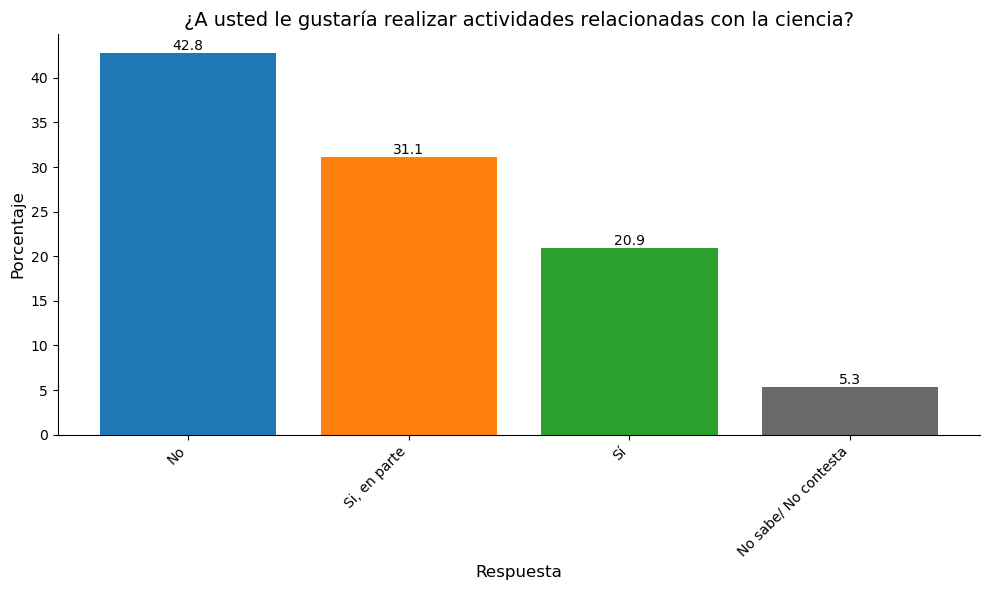

ValueError: could not convert string to float: 'dimgray'

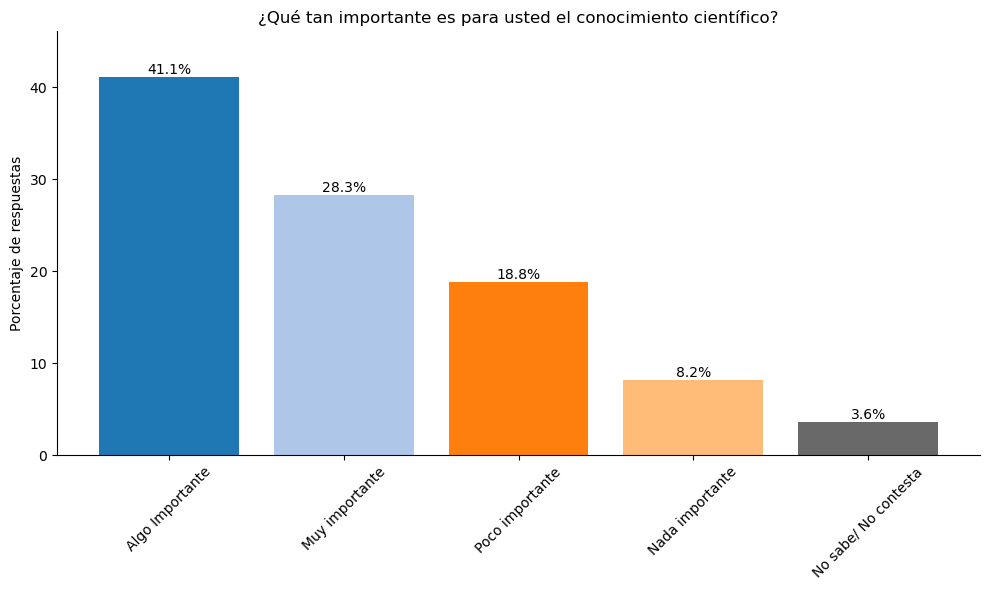

In [ ]:

tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

tmp_plot_res_dict = {}
exec(tmp_agg_out_lst)
## TODO: arreglar esto. 

In [ ]:
# reimportar el dict devuelto por el modelo
import ast

answer_text = answer.text.strip("```python").strip("```")
sel_dict = ast.literal_eval(answer_text)
sel_dict

In [ ]:
tmp_sel_dict = {k.split('|')[1]:v for k,v in sel_dict.items()}

{'p33': 'En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?',
 'p45_1': 'Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla',
 'p50_4': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales',
 'p34': 'Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?',
 'p36': '¿Qué tan importante es para usted el conocimiento científico?',
 'p52': '¿Qué tan importante es para México generar tecnología propia?',
 'p11': '¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?',
 'p37_6': 'Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos',
 'p13_1': '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN',


'p52'

In [283]:
tmp_val_etq_dict['p52']

{1.0: 'Muy importante',
 2.0: 'Importante',
 3.0: 'Regular',
 4.0: 'Poco importante',
 5.0: 'Nada importante',
 9.0: 'No sabe/ No contesta'}

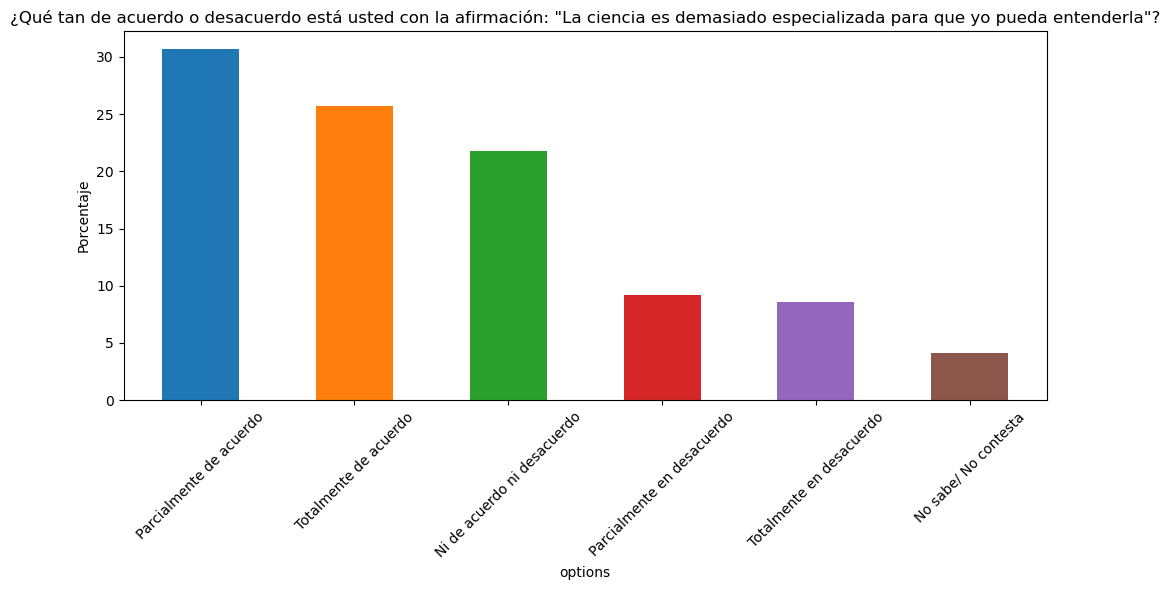

In [321]:
import pandas as pd
import matplotlib.pyplot as plt
import io

data = {'options': ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo', 'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta'],
        'percentage': [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]}

df = pd.DataFrame(data)
df = df.set_index('options')
df.columns = ['p45_1']

# Creating the plot
def create_plot(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    df['p45_1'].sort_values(ascending=False).plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']) # Use different colors
    ax.set_ylabel('Porcentaje')
    ax.set_title('¿Qué tan de acuerdo o desacuerdo está usted con la afirmación: "La ciencia es demasiado especializada para que yo pueda entenderla"?')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    # # Convert plot to base64 string
    # img_data = io.BytesIO()
    # fig.savefig(img_data, format='png')
    # img_data.seek(0)
    
    return fig

plot = create_plot(df)
plt.show()

In [271]:
enc_dict[enc_ID]['dataframe'][tmp_var_lst].describe()

,p33,p45_1,p50_4,p34,p36,p52,p11,p37_6,p13_1,p35
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1194.000000,1200.000000,1200.000000,1200.000000
mean,2.633333,2.665833,2.445833,2.900833,2.292500,1.850833,2.771357,3.781667,6.067500,2.542500
std,1.970734,1.697518,1.966033,1.939278,1.457297,1.444641,1.095820,1.678197,13.121411,1.534108
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,3.000000,2.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,4.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4.000000,7.000000,3.000000
max,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,99.000000,9.000000


In [ ]:
# # generación aumentada: prompt + pregunta + documentos 

# query_oneline = query.replace("\n", " ")

# # This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
# prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
# Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
# However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
# strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

# QUESTION: {query_oneline}
# """

# # Add the retrieved documents to the prompt.
# for passage in all_passages:
#     passage_oneline = passage.replace("\n", " ")
#     prompt += f"PASSAGE: {passage_oneline}\n"

# print(prompt)

In [ ]:
# las columnas terminadas en 'a' son aparentemente idénticas a las que no... 

filtered_columns = enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$')
value_counts_df = pd.DataFrame({col: filtered_columns[col].value_counts() for col in filtered_columns.columns}).fillna(0).astype(int)
filtered_columns, value_counts_df

(      p14_1a  p14_2a  p14_3a  p15_1a  p15_2a  p15_3a  p20_1a  p20_2a  p20_3a  \
 0        3.0     2.0     5.0     9.0     6.0     7.0    10.0     5.0     4.0   
 1        2.0     3.0     4.0    12.0     6.0     NaN     NaN     NaN     NaN   
 2        3.0     5.0     4.0     7.0     2.0     6.0     2.0     6.0    10.0   
 3        3.0     5.0     NaN     2.0     7.0    10.0     6.0    10.0     4.0   
 4        9.0     NaN     NaN    11.0     NaN     NaN     NaN     NaN     NaN   
 ...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
 1195     3.0     4.0     NaN     1.0     NaN     NaN     NaN     NaN     NaN   
 1196     3.0     5.0     NaN     3.0     NaN     NaN     4.0    10.0     NaN   
 1197     3.0     4.0     NaN     2.0     3.0     7.0     NaN     NaN     NaN   
 1198     3.0     5.0     NaN     1.0     2.0     7.0     1.0     4.0    10.0   
 1199     3.0     NaN     NaN     2.0     1.0     NaN     NaN     NaN     NaN   
 
       p29_1a  p29_2a  p29

In [ ]:
filtered_columns.columns.str.rstrip('a')
enc_dict['Ciencia_y_Tecnologia']['dataframe'][filtered_columns.columns.str.rstrip('a')]

,p14_1,p14_2,p14_3,p15_1,p15_2,p15_3,p20_1,p20_2,p20_3,p29_1,p29_2,p29_3,p46_1,p46_2,p46_3,p47_1,p47_2,p47_3,p53,p54
0,3.0,2.0,5.0,9.0,6.0,7.0,10.0,5.0,4.0,10.0,4.0,6.0,10.0,1.0,7.0,3.0,9.0,1.0,2.0,2.0
1,2.0,3.0,4.0,12.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,9.0,3.0,4.0,7.0,2.0,2.0
2,3.0,5.0,4.0,7.0,2.0,6.0,2.0,6.0,10.0,NaN,NaN,NaN,7.0,1.0,10.0,7.0,1.0,10.0,2.0,1.0
3,3.0,5.0,NaN,2.0,7.0,10.0,6.0,10.0,4.0,NaN,NaN,NaN,5.0,4.0,10.0,2.0,6.0,7.0,2.0,2.0
4,9.0,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.0,NaN,NaN,1.0,6.0,10.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,3.0,4.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN,5.0,2.0,NaN,2.0,2.0
1196,3.0,5.0,NaN,3.0,NaN,NaN,4.0,10.0,NaN,NaN,NaN,NaN,8.0,6.0,10.0,8.0,6.0,10.0,2.0,2.0
1197,3.0,4.0,NaN,2.0,3.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,5.0,10.0,2.0,5.0,10.0,2.0,2.0
1198,3.0,5.0,NaN,1.0,2.0,7.0,1.0,4.0,10.0,1.0,4.0,NaN,2.0,9.0,10.0,2.0,9.0,10.0,2.0,2.0


In [110]:
result

Index(['p1_1a_1', 'p1_2a_1', 'p1_3a_1', 'p2_1a_1', 'p2_2a_1', 'p2_3a_1',
       'p14_1a', 'p14_2a', 'p14_3a', 'p15_1a', 'p15_2a', 'p15_3a', 'p20_1a',
       'p20_2a', 'p20_3a', 'p29_1a', 'p29_2a', 'p29_3a', 'p46_1a', 'p46_2a',
       'p46_3a', 'p47_1a', 'p47_2a', 'p47_3a', 'p53a', 'p53aa_1', 'p54a'],
      dtype='object')

In [114]:
result_a = enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$').columns
base_a = [col.rstrip('_a') for col in result_a]
enc_dict['Ciencia_y_Tecnologia']['dataframe'][base_a].describe()

# base_colnames = [col.rstrip('a_1').rstrip('_a') for col in result]
# matching_colnames = [col for col in enc_dict['Ciencia_y_Tecnologia']['dataframe'].columns if any(base in col for base in base_colnames)]
# result, base_colnames, matching_colnames

,p14_1,p14_2,p14_3,p15_1,p15_2,p15_3,p20_1,p20_2,p20_3,p29_1,p29_2,p29_3,p46_1,p46_2,p46_3,p47_1,p47_2,p47_3,p53,p54
count,1200.000000,623.000000,312.000000,1200.000000,728.000000,457.000000,322.000000,226.000000,153.000000,308.000000,173.000000,87.000000,1200.000000,1006.000000,849.000000,1200.000000,975.000000,802.000000,1200.000000,1200.000000
mean,6.783333,3.762440,4.227564,8.190833,4.295330,5.750547,7.478261,5.420354,6.882353,6.081169,5.369942,6.172414,13.755000,5.516899,6.799764,13.255000,5.502564,7.056110,11.133333,2.110000
std,15.401430,1.487807,1.969905,16.777733,2.920191,3.025318,15.013011,2.988174,3.069247,10.966483,2.724057,2.548173,29.463877,7.160923,2.948049,28.608513,2.780791,2.859261,28.512711,1.316945
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,1.000000,2.000000,5.000000,2.000000,3.000000,5.000000,2.000000,2.000000
50%,3.000000,4.000000,4.000000,6.000000,3.000000,6.000000,4.000000,5.000000,7.000000,4.000000,5.000000,6.000000,3.000000,5.000000,7.000000,3.000000,6.000000,8.000000,2.000000,2.000000
75%,5.000000,5.000000,5.000000,10.000000,7.000000,8.000000,8.000000,8.000000,10.000000,6.000000,7.000000,8.000000,7.000000,7.000000,9.000000,7.000000,7.000000,9.000000,2.000000,2.000000
max,99.000000,13.000000,12.000000,99.000000,14.000000,14.000000,99.000000,14.000000,14.000000,99.000000,15.000000,13.000000,99.000000,99.000000,17.000000,99.000000,15.000000,14.000000,99.000000,9.000000


In [115]:
enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$').describe()


,p14_1a,p14_2a,p14_3a,p15_1a,p15_2a,p15_3a,p20_1a,p20_2a,p20_3a,p29_1a,p29_2a,p29_3a,p46_1a,p46_2a,p46_3a,p47_1a,p47_2a,p47_3a,p53a,p54a
count,1200.000000,623.000000,312.000000,1200.000000,728.000000,457.000000,322.000000,226.000000,153.000000,308.000000,173.000000,87.000000,1200.000000,1006.000000,849.000000,1200.000000,975.000000,802.000000,1200.00000,171.000000
mean,6.783333,3.756019,4.208333,8.180000,4.281593,5.746171,7.391304,5.407080,6.862745,5.925325,5.271676,6.137931,13.751667,5.512922,6.792697,13.241667,5.495385,7.052369,2.96250,12.321637
std,15.401430,1.455069,1.902324,16.774547,2.878864,3.014787,14.982097,2.956386,3.032844,10.883643,2.482768,2.473922,29.463708,7.155093,2.927890,28.608308,2.761894,2.852119,12.33523,27.966504
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.00000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,1.000000,2.000000,5.000000,2.000000,3.000000,5.000000,-1.00000,2.000000
50%,3.000000,4.000000,4.000000,6.000000,3.000000,6.000000,4.000000,5.000000,7.000000,4.000000,5.000000,6.000000,3.000000,5.000000,7.000000,3.000000,6.000000,8.000000,-1.00000,4.000000
75%,5.000000,5.000000,5.000000,10.000000,7.000000,8.000000,8.000000,8.000000,10.000000,6.000000,7.000000,8.000000,7.000000,7.000000,9.000000,7.000000,7.000000,9.000000,-1.00000,5.000000
max,99.000000,10.000000,10.000000,99.000000,12.000000,12.000000,99.000000,11.000000,11.000000,99.000000,10.000000,10.000000,99.000000,99.000000,14.000000,99.000000,11.000000,11.000000,99.00000,99.000000


In [ ]:
enc_dict['Ciencia_y_Tecnologia']['metadata']['variable_value_labels']['p16']

{98.0: 'NS', 99.0: 'NC'}

In [ ]:
enc_dict['Ciencia_y_Tecnologia']['dataframe']['p16']

0       5.0
1       2.0
2       6.0
3       7.0
4       6.0
       ... 
1195    3.0
1196    6.0
1197    5.0
1198    8.0
1199    6.0
Name: p16, Length: 1200, dtype: float64

In [ ]:
pregs_dict.values()

dict_values(['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  2° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  3° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° M

In [ ]:
from collections import Counter

# Identify non-unique elements in the list
non_unique_elements = [item for item, count in Counter(list(pregs_dict.values())).items() if count > 1]
non_unique_elements

['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN',
 '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN',
 '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  2° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  3° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  1° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  2° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  3° MENCIÓN',
 ' 15 Cuando estaba en la escuela o en sus estudios ¿De quién o quienes recibía (recibe) apoyo para realizar

In [ ]:
len(non_unique_elements)

25

### sigue debajo

In [28]:
# crea un ciente de chromadb - y fija document_mode a True

# import chromadb

# DB_NAME = "googlecardb"

# embed_fn = GeminiEmbeddingFunction()
# embed_fn.document_mode = True

# chroma_client = chromadb.Client()
# db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)

# db.add(documents=documents, ids=[str(i) for i in range(len(documents))])

In [29]:
# db.count(), db.peek()

In [30]:
# results = db.get()

# results

# print("IDs:", results["ids"])
# print("Documents:", results["documents"])
# print("Embeddings:", results["embeddings"])
# print("Metadatas:", results["metadatas"])

# # ChromaDB does not store embeddings by default for efficiency reasons.
# # To retrieve embeddings, you need to query the database instead of using `db.get()`.

# query_results = db.query(query_texts=[""], n_results=db.count())
# print("Embeddings:", query_results["embeddings"])

In [31]:
# # Switch to query mode when generating embeddings.
# embed_fn.document_mode = False

# # Search the Chroma DB using the specified query.
# query = "How do you use the touchscreen to play music?"

# result = db.query(query_texts=[query], n_results=1)
# [all_passages] = result["documents"]

# Markdown(all_passages[0])

In [32]:
# # generación aumentada: prompt + pregunta + documentos 

# query_oneline = query.replace("\n", " ")

# # This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
# prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
# Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
# However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
# strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

# QUESTION: {query_oneline}
# """

# # Add the retrieved documents to the prompt.
# for passage in all_passages:
#     passage_oneline = passage.replace("\n", " ")
#     prompt += f"PASSAGE: {passage_oneline}\n"

# print(prompt)

In [33]:
# answer = client.models.generate_content(
#     model="gemini-2.0-flash",
#     contents=prompt)

# Markdown(answer.text)

#### similarity scores

In [34]:
# calcular la similitud entre documentos

texts = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick rbown fox jumps over the lazy dog.',
    'teh fast fox jumps over the slow woofer.',
    'a quick brown fox jmps over lazy dog.',
    'brown fox jumping over dog',
    'fox > dog',
    # Alternative pangram for comparison:
    'The five boxing wizards jump quickly.',
    # Unrelated text, also for comparison:
    'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus.',
]


response = client.models.embed_content(
    model='models/text-embedding-004',
    contents=texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))

In [35]:
# el modelo de embeddings como diccionario y los embeddings directos    
response.model_dump(), response.embeddings

({'embeddings': [{'values': [-0.0922682,
     0.012113783,
     -0.0063794684,
     0.0369048,
     0.02203019,
     0.048805293,
     0.0133289965,
     0.021541007,
     0.02705553,
     -0.0043925485,
     -0.011962657,
     0.069833845,
     0.010891116,
     0.06149802,
     0.049922608,
     0.022119658,
     0.0178632,
     0.050096616,
     0.0029887455,
     -0.008278692,
     0.005999019,
     -0.0040636063,
     0.015202278,
     -0.021813663,
     -0.02274539,
     -0.032121718,
     -0.00033075613,
     -0.022031343,
     0.028694874,
     -0.04976425,
     0.025347114,
     0.07245508,
     0.003248612,
     -0.002201165,
     0.059787363,
     -0.0057624904,
     -0.02634191,
     -0.003782781,
     0.048398733,
     0.0066004205,
     -0.05704449,
     -0.022870814,
     -0.058460187,
     0.013212032,
     0.01834201,
     -0.076267265,
     -0.02015255,
     0.014425502,
     0.0024263572,
     -0.011807308,
     0.056245767,
     -0.0031448188,
     0.0013501083,
   

In [36]:
# la longitud de los embeddings es fija
len(response.embeddings[0].values)

768

In [37]:
# truncar datos para visualización

def truncate(t: str, limit: int = 50) -> str:
  """Truncate labels to fit on the chart."""
  if len(t) > limit:
    return t[:limit-3] + '...'
  else:
    return t

truncated_texts = [truncate(t) for t in texts]

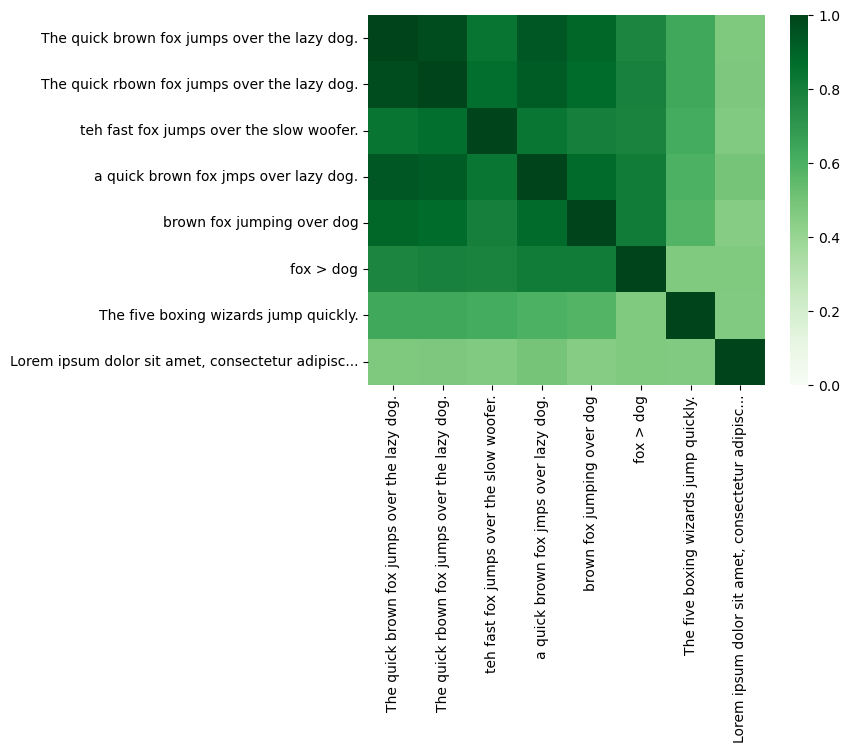

In [38]:
# la similaridad se calcula como el producto punto (inner product) entre los vectores de embedding

import pandas as pd
import seaborn as sns


# Set up the embeddings in a dataframe.
df = pd.DataFrame([e.values for e in response.embeddings], index=truncated_texts)

# la matriz de similardad: 
# Perform the similarity calculation
sim = df @ df.T
# Draw!
sns.heatmap(sim, vmin=0, vmax=1, cmap="Greens");

In [39]:
# sim is a similarity matrix calculated as the dot product of embedding vectors.
# Each entry in sim represents the similarity score between two text embeddings.
sim['The quick brown fox jumps over the lazy dog.'].sort_values(ascending=False)

The quick brown fox jumps over the lazy dog.          0.999999
The quick rbown fox jumps over the lazy dog.          0.975623
a quick brown fox jmps over lazy dog.                 0.939730
brown fox jumping over dog                            0.894507
teh fast fox jumps over the slow woofer.              0.842152
fox > dog                                             0.776455
The five boxing wizards jump quickly.                 0.635346
Lorem ipsum dolor sit amet, consectetur adipisc...    0.472174
Name: The quick brown fox jumps over the lazy dog., dtype: float64

#### clasificación de embeddings con Keras

In [40]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset="train")
newsgroups_test = fetch_20newsgroups(subset="test")

# View list of class names for dataset
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [41]:
print(newsgroups_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [42]:
# # preprocesamiento como un mensaje anónimo

# import email
# import re

# import pandas as pd


# def preprocess_newsgroup_row(data):
#     # Extract only the subject and body
#     msg = email.message_from_string(data)
#     text = f"{msg['Subject']}\n\n{msg.get_payload()}"
#     # Strip any remaining email addresses
#     text = re.sub(r"[\w\.-]+@[\w\.-]+", "", text)
#     # Truncate each entry to 5,000 characters
#     text = text[:5000]

#     return text


# def preprocess_newsgroup_data(newsgroup_dataset):
#     # Put data points into dataframe
#     df = pd.DataFrame(
#         {"Text": newsgroup_dataset.data, "Label": newsgroup_dataset.target}
#     )
#     # Clean up the text
#     df["Text"] = df["Text"].apply(preprocess_newsgroup_row)
#     # Match label to target name index
#     df["Class Name"] = df["Label"].map(lambda l: newsgroup_dataset.target_names[l])

#     return df

In [43]:
# # Apply preprocessing function to training and test datasets
# df_train = preprocess_newsgroup_data(newsgroups_train)
# df_test = preprocess_newsgroup_data(newsgroups_test)

# df_train.head()

,Text,Label,Class Name
0,WHAT car is this!?\n\n I was wondering if anyo...,7,rec.autos
1,SI Clock Poll - Final Call\n\nA fair number of...,4,comp.sys.mac.hardware
2,"PB questions...\n\nwell folks, my mac plus fin...",4,comp.sys.mac.hardware
3,Re: Weitek P9000 ?\n\nRobert J.C. Kyanko () wr...,1,comp.graphics
4,Re: Shuttle Launch Question\n\nFrom article <>...,14,sci.space


In [44]:
# # muestra de datos y selección de mensajes de ciencia
# def sample_data(df, num_samples, classes_to_keep):
#     # Sample rows, selecting num_samples of each Label.
#     df = (
#         df.groupby("Label")[df.columns]
#         .apply(lambda x: x.sample(num_samples))
#         .reset_index(drop=True)
#     )

#     df = df[df["Class Name"].str.contains(classes_to_keep)]

#     # We have fewer categories now, so re-calibrate the label encoding.
#     df["Class Name"] = df["Class Name"].astype("category")
#     df["Encoded Label"] = df["Class Name"].cat.codes

#     return df

In [45]:
# TRAIN_NUM_SAMPLES = 100
# TEST_NUM_SAMPLES = 25
# # Class name should contain 'sci' to keep science categories.
# # Try different labels from the data - see newsgroups_train.target_names
# CLASSES_TO_KEEP = "sci"

# df_train = sample_data(df_train, TRAIN_NUM_SAMPLES, CLASSES_TO_KEEP)
# df_test = sample_data(df_test, TEST_NUM_SAMPLES, CLASSES_TO_KEEP)

In [46]:
# df_train.value_counts("Class Name")

Class Name
sci.crypt          100
sci.electronics    100
sci.med            100
sci.space          100
Name: count, dtype: int64

#### clasificación

In [47]:
## el modelo de embeddings se puede usar para varias tareas

# Task types
# The text-embedding-004 model supports a task type parameter that generates embeddings tailored for the specific task.

# Task Type	Description
# RETRIEVAL_QUERY	Specifies the given text is a query in a search/retrieval setting.
# RETRIEVAL_DOCUMENT	Specifies the given text is a document in a search/retrieval setting.
# SEMANTIC_SIMILARITY	Specifies the given text will be used for Semantic Textual Similarity (STS).
# CLASSIFICATION	Specifies that the embeddings will be used for classification.
# CLUSTERING	Specifies that the embeddings will be used for clustering.
# FACT_VERIFICATION	Specifies that the given text will be used for fact verification.
# For this example you will be performing classification.

In [48]:
# # clasificación de texto

# from google.api_core import retry
# import tqdm
# from tqdm.rich import tqdm as tqdmr
# import warnings

# # Add tqdm to Pandas...
# tqdmr.pandas()

# # ...But suppress the experimental warning.
# warnings.filterwarnings("ignore", category=tqdm.TqdmExperimentalWarning)

# # Define a helper to retry when per-minute quota is reached.
# is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

# @retry.Retry(predicate=is_retriable, timeout=300.0)
# def embed_fn(text: str) -> list[float]:
#     # You will be performing classification, so set task_type accordingly.
#     response = client.models.embed_content(
#         model="models/text-embedding-004",
#         contents=text,
#         config=types.EmbedContentConfig(
#             task_type="classification",
#         ),
#     )

#     return response.embeddings[0].values


# def create_embeddings(df):
#     df["Embeddings"] = df["Text"].progress_apply(embed_fn)
#     return df

In [49]:
#toma aprox 4 -8 mins

# df_train = create_embeddings(df_train)
# df_test = create_embeddings(df_test)

In [50]:
# df_train.head()

In [51]:
# # construcción de un modelo de clasificación con keras

# import keras
# from keras import layers


# def build_classification_model(input_size: int, num_classes: int) -> keras.Model:
#     return keras.Sequential(
#         [
#             layers.Input([input_size], name="embedding_inputs"),
#             layers.Dense(input_size, activation="relu", name="hidden"),
#             layers.Dense(num_classes, activation="softmax", name="output_probs"),
#         ]
#     )

In [52]:
# # Derive the embedding size from observing the data. The embedding size can also be specified
# # with the `output_dimensionality` parameter to `embed_content` if you need to reduce it.
# embedding_size = len(df_train["Embeddings"].iloc[0])

# classifier = build_classification_model(
#     embedding_size, len(df_train["Class Name"].unique())
# )
# classifier.summary()

# classifier.compile(
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     metrics=["accuracy"],
# )

In [53]:
# # modelo de clasificación
# # The model is compiled and ready to train.

# import numpy as np


# NUM_EPOCHS = 20
# BATCH_SIZE = 32

# # Split the x and y components of the train and validation subsets.
# y_train = df_train["Encoded Label"]
# x_train = np.stack(df_train["Embeddings"])
# y_val = df_test["Encoded Label"]
# x_val = np.stack(df_test["Embeddings"])

# # Specify that it's OK to stop early if accuracy stabilises.
# early_stop = keras.callbacks.EarlyStopping(monitor="accuracy", patience=3)

# # Train the model for the desired number of epochs.
# history = classifier.fit(
#     x=x_train,
#     y=y_train,
#     validation_data=(x_val, y_val),
#     callbacks=[early_stop],
#     batch_size=BATCH_SIZE,
#     epochs=NUM_EPOCHS,
# )

In [54]:
# evaluación del modelo

# classifier.evaluate(x=x_val, y=y_val, return_dict=True)

In [55]:
# def make_prediction(text: str) -> list[float]:
#     """Infer categories from the provided text."""
#     # Remember that the model takes embeddings as input, so calculate them first.
#     embedded = embed_fn(new_text)

#     # And recall that the input must be batched, so here they are wrapped as a
#     # list to provide a batch of 1.
#     inp = np.array([embedded])

#     # And un-batched here.
#     [result] = classifier.predict(inp)
#     return result

In [56]:
# # This example avoids any space-specific terminology to see if the model avoids
# # biases towards specific jargon.
# new_text = """
# First-timer looking to get out of here.

# Hi, I'm writing about my interest in travelling to the outer limits!

# What kind of craft can I buy? What is easiest to access from this 3rd rock?

# Let me know how to do that please.
# """

# result = make_prediction(new_text)

# for idx, category in enumerate(df_test["Class Name"].cat.categories):
#     print(f"{category}: {result[idx] * 100:0.2f}%")